In [1]:
import joblib
from analysis_utils import *

# Görselleştirme Ayarları
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [2]:
# --- 1. Upload Data ---
df = pd.read_csv("../datasets/cancer_data.csv")
print(f"1. Veri Yüklendi. Boyut: {df.shape}")

1. Veri Yüklendi. Boyut: (569, 33)


In [3]:
# --- 2. Genel Yapı, Tipler ve Eksik Veri Analizi ---
check_general_structure(df)

=== Veri Tipleri ve Non-Null Bilgisi ===
<class 'pandas.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    int64  
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 

,Eksik Sayısı,Eksik Oranı (%)
id,0,0.0
diagnosis,0,0.0
radius_mean,0,0.0
texture_mean,0,0.0
perimeter_mean,0,0.0
area_mean,0,0.0
smoothness_mean,0,0.0
compactness_mean,0,0.0
concavity_mean,0,0.0
concave points_mean,0,0.0


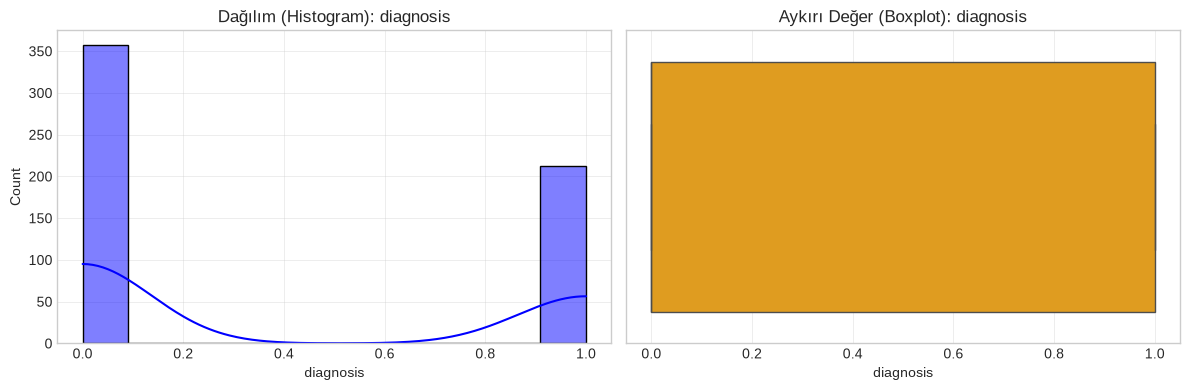

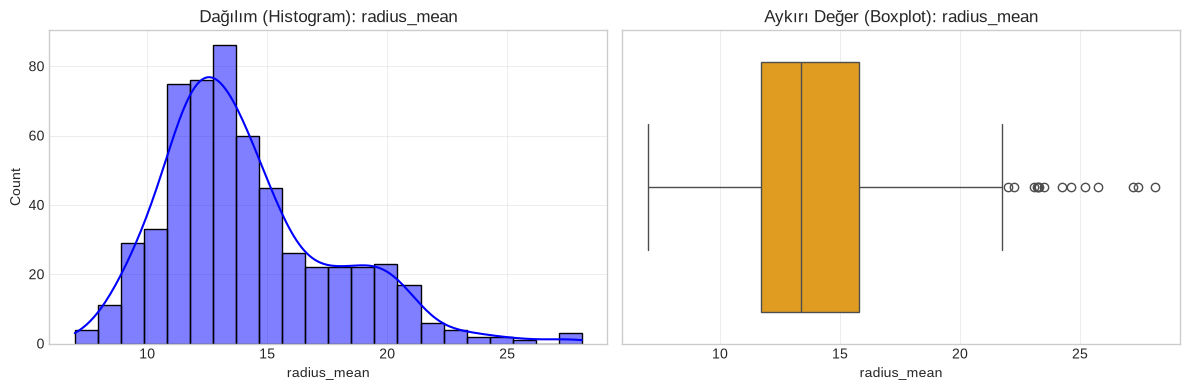

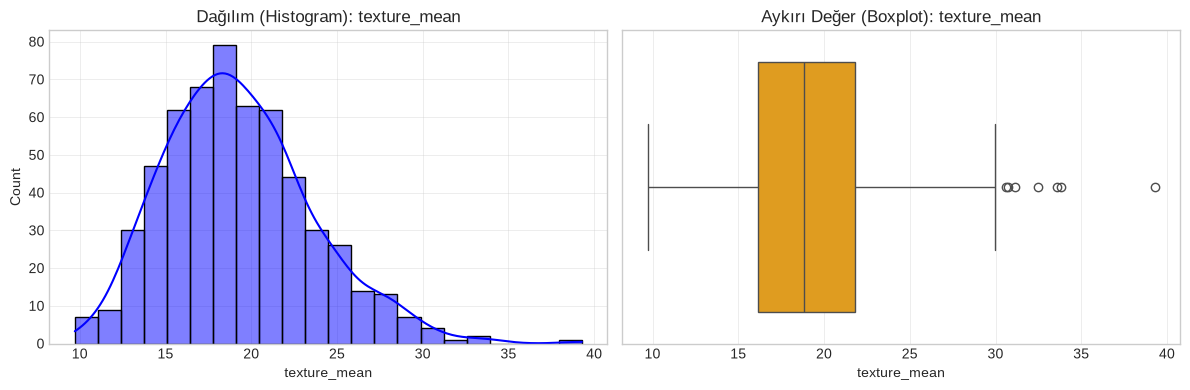

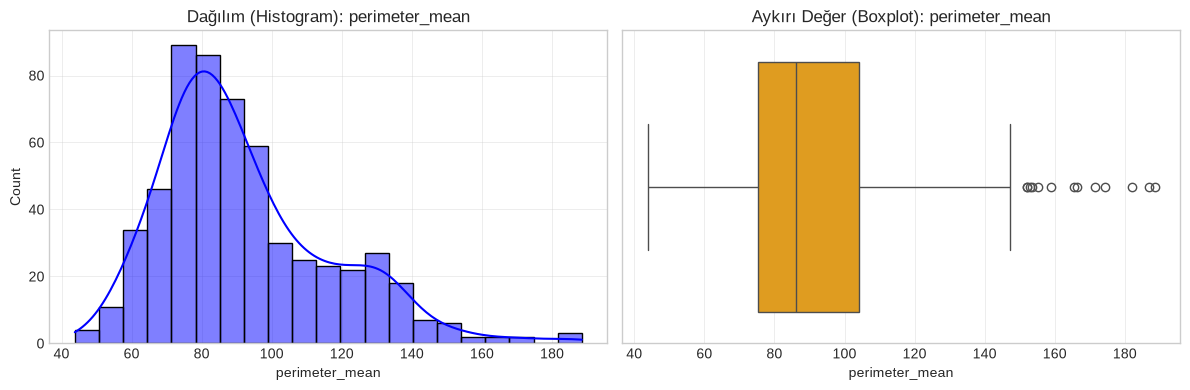

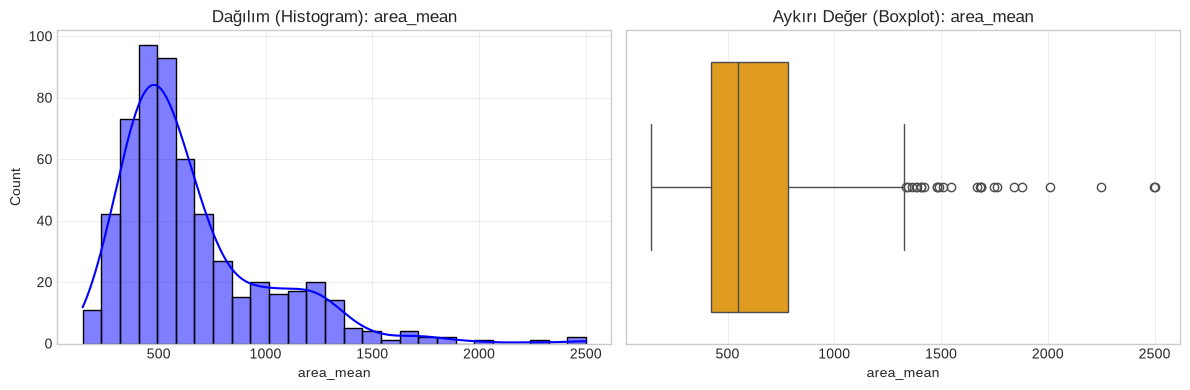

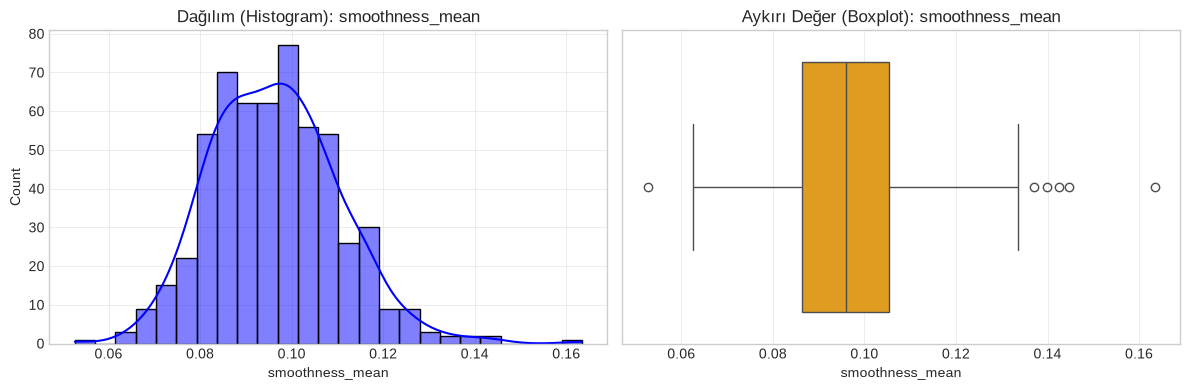

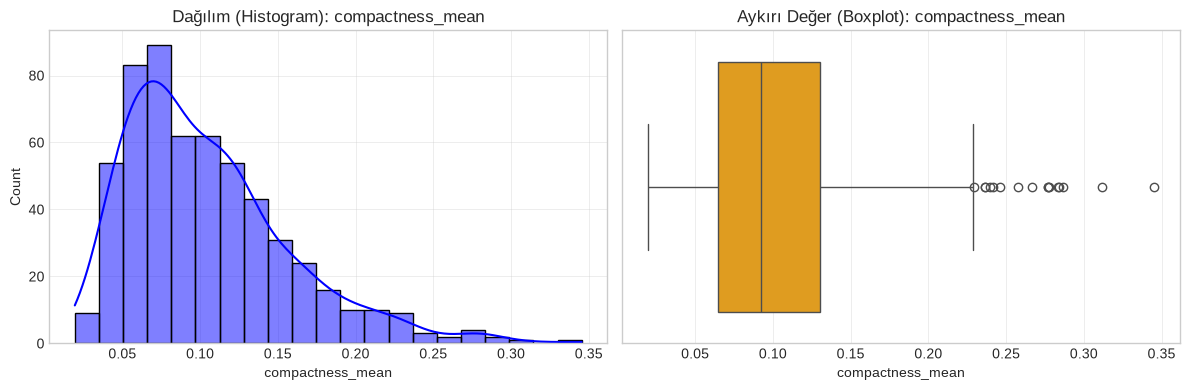

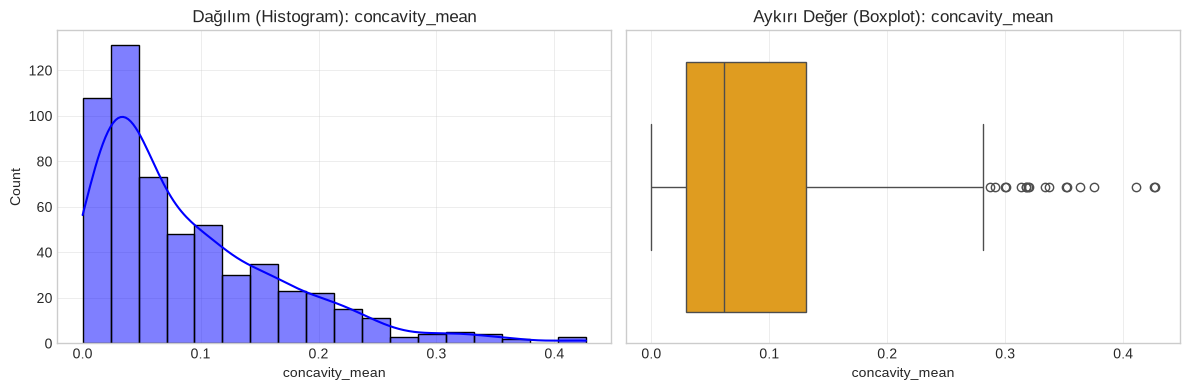

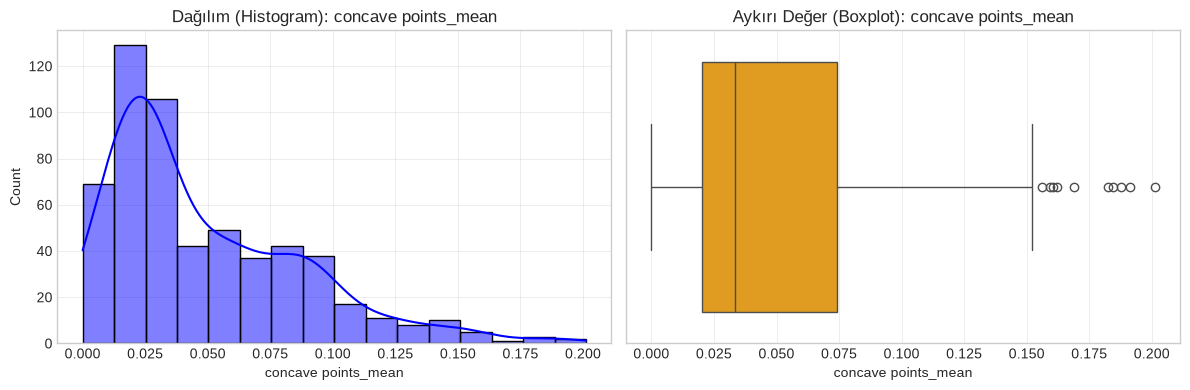

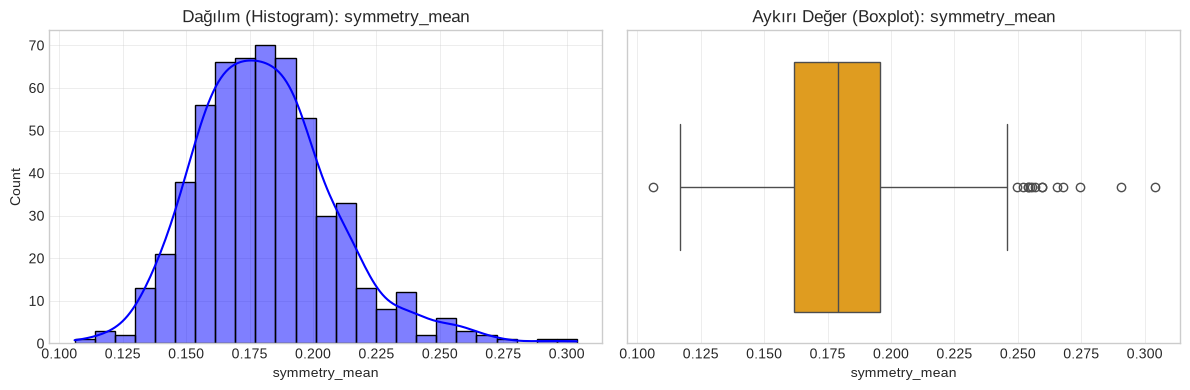

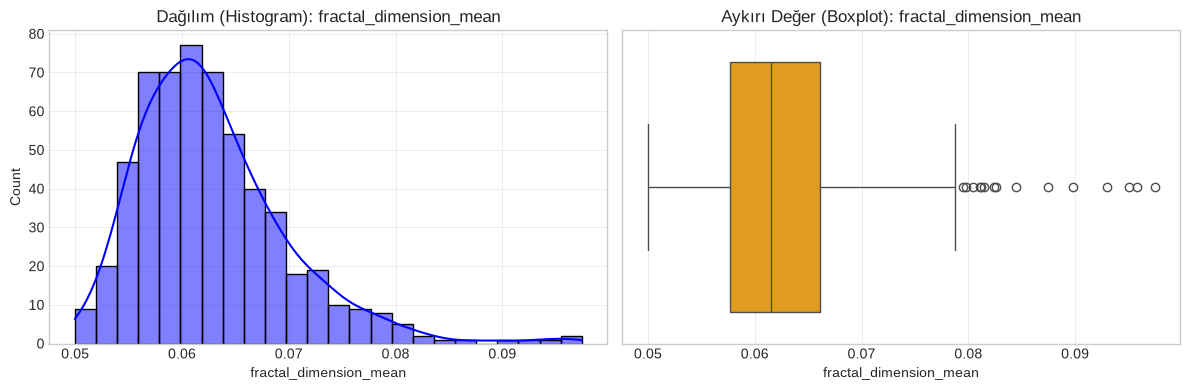

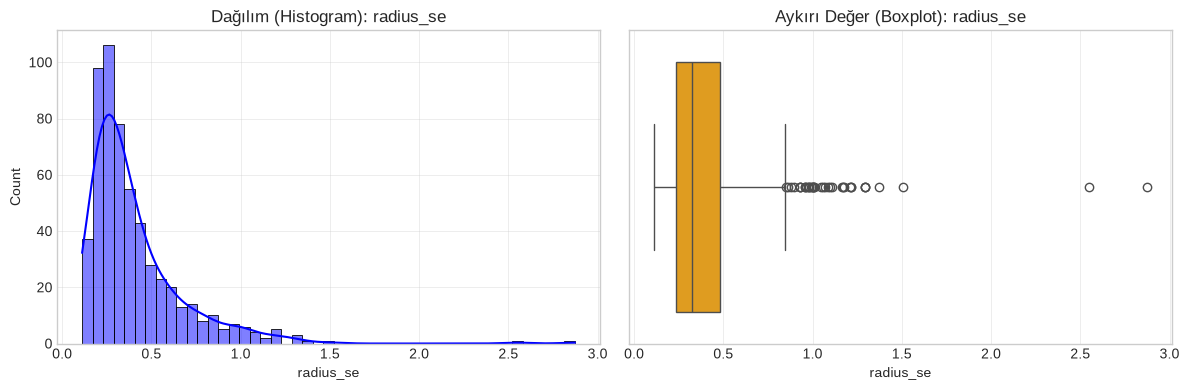

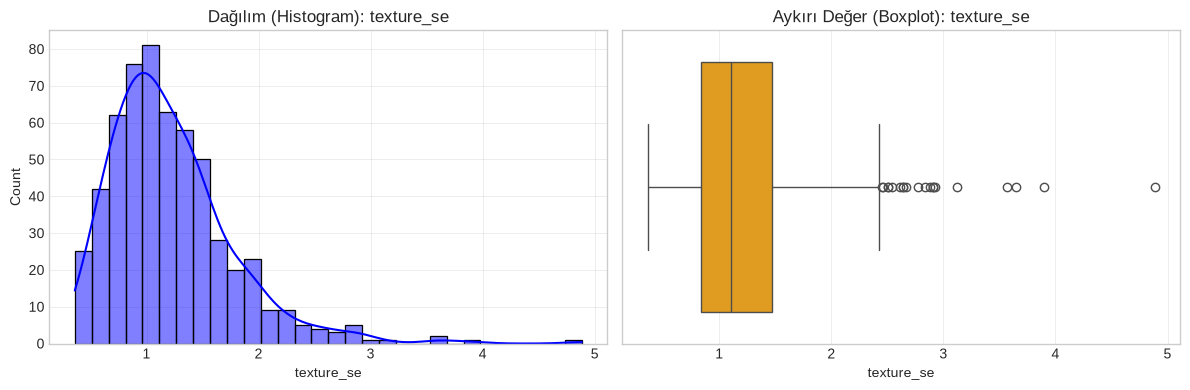

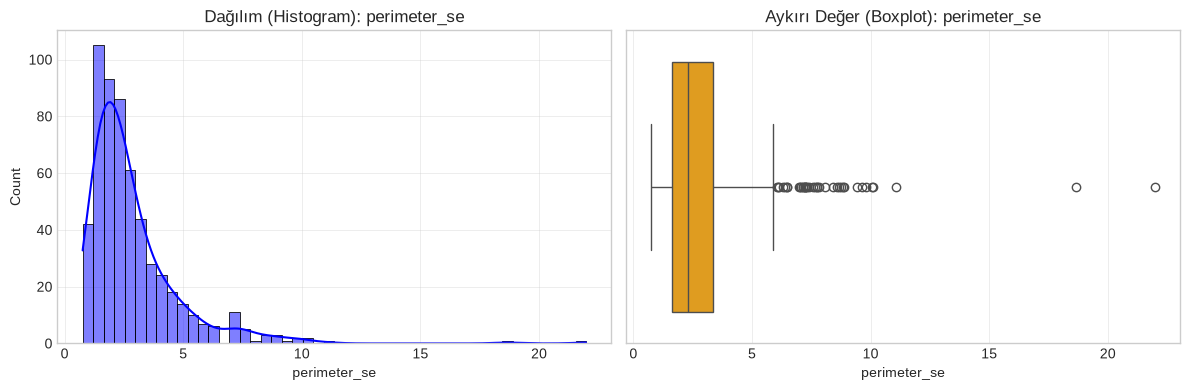

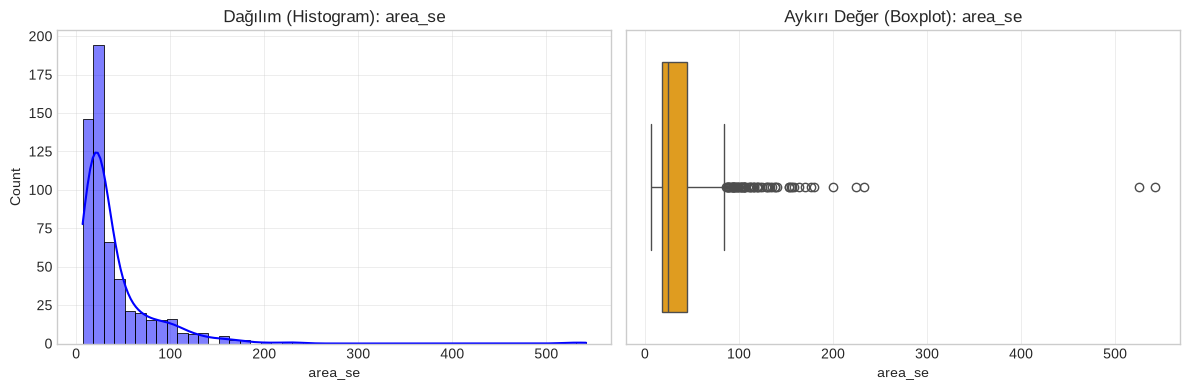

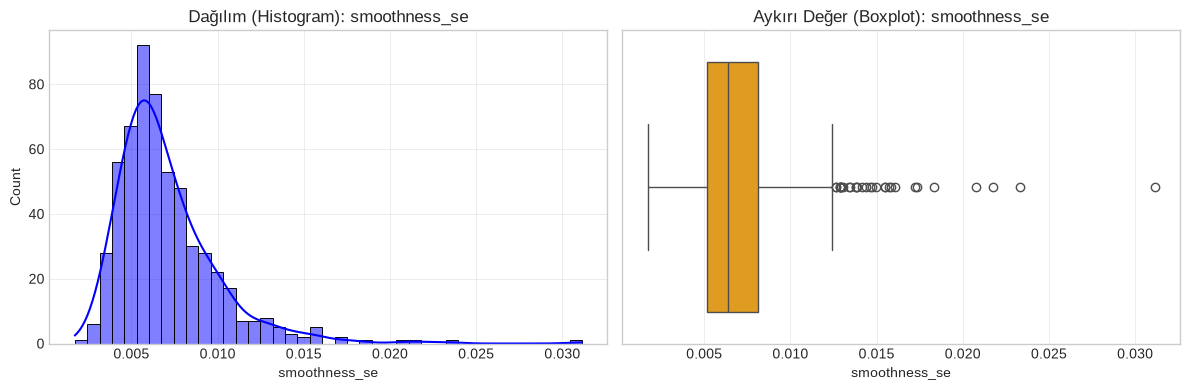

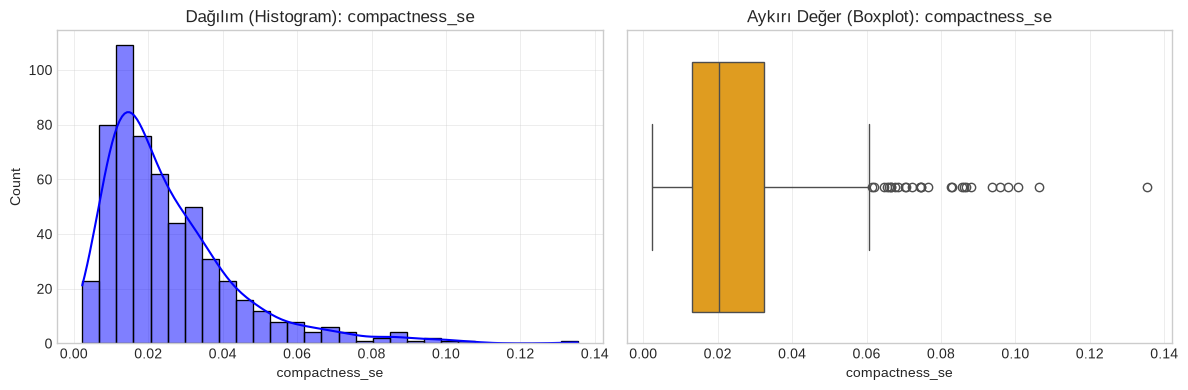

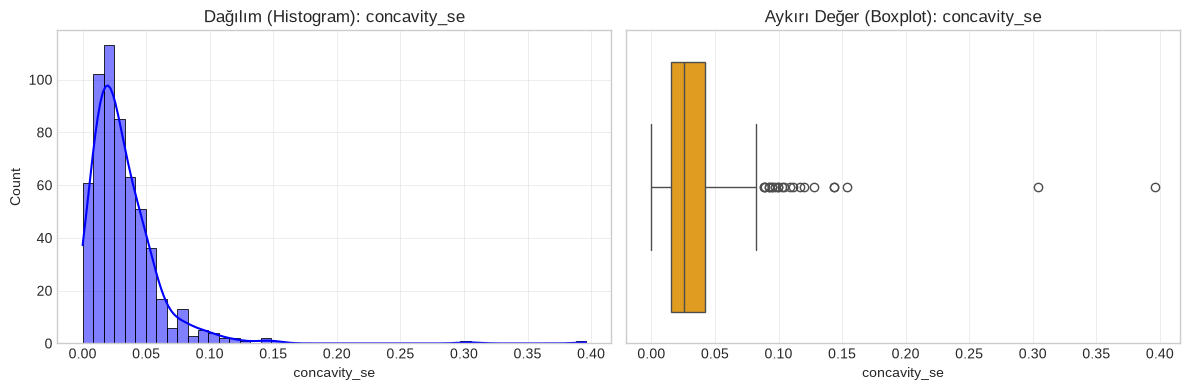

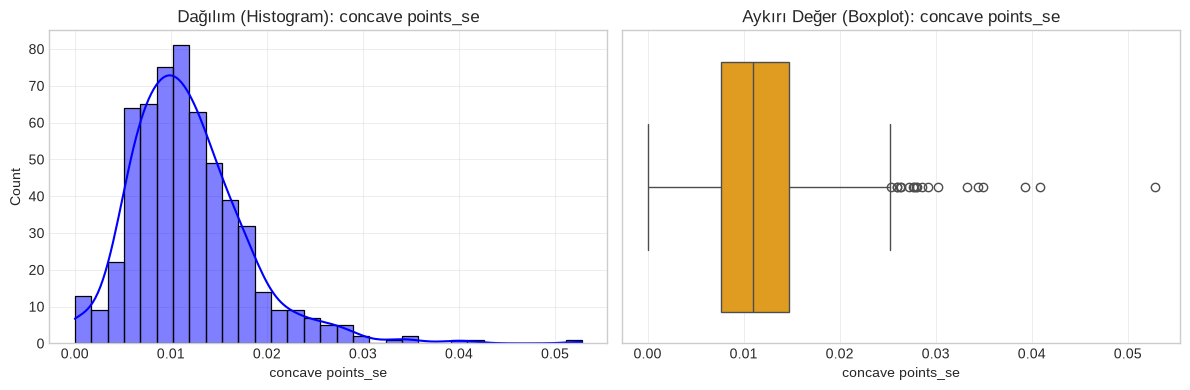

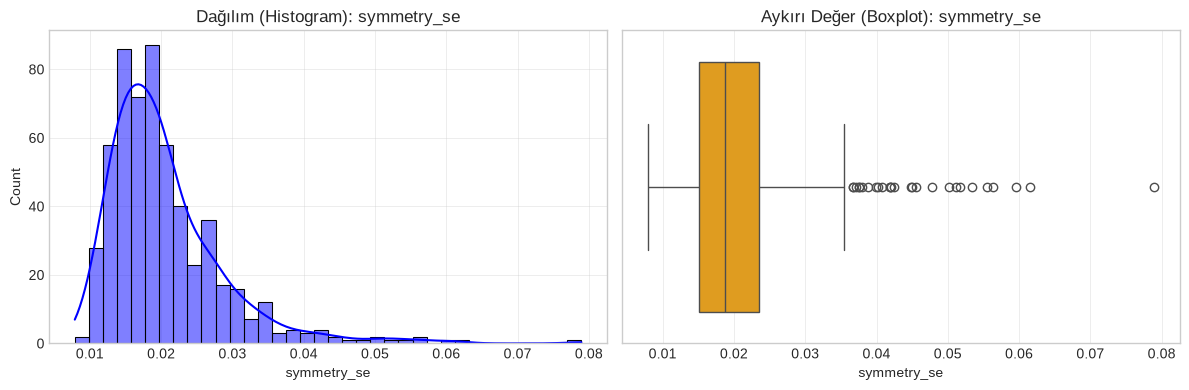

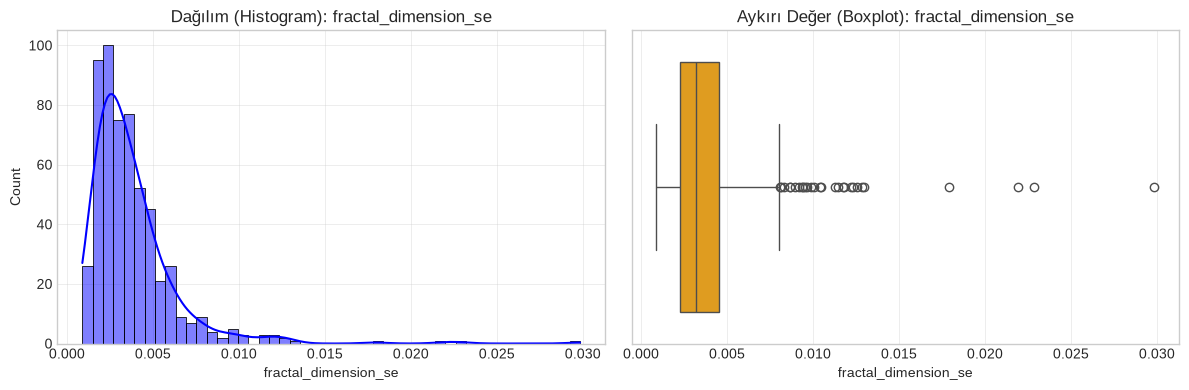

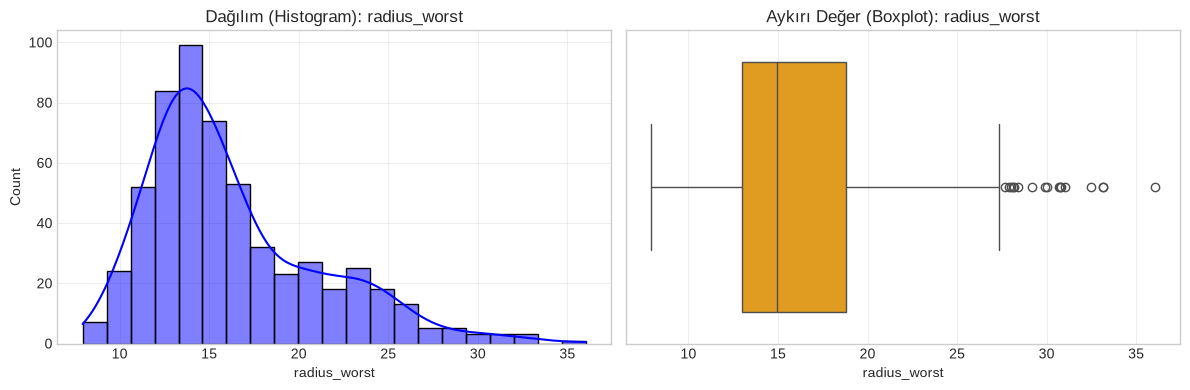

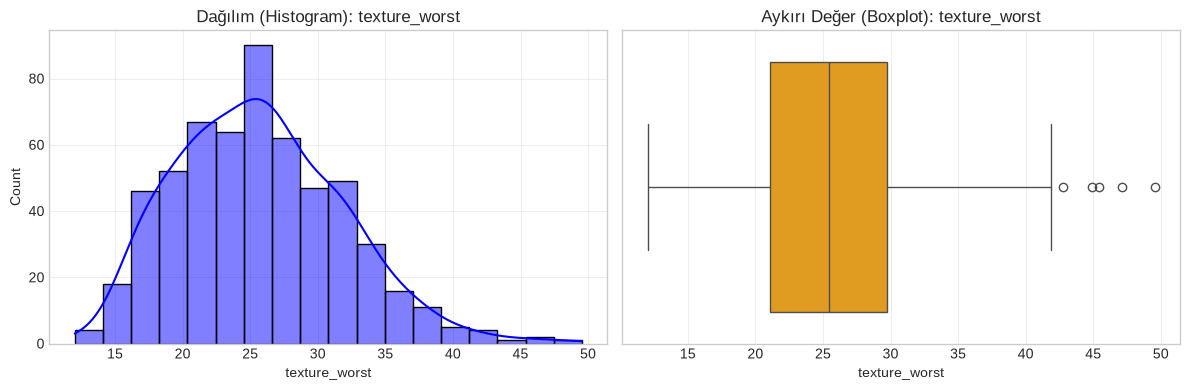

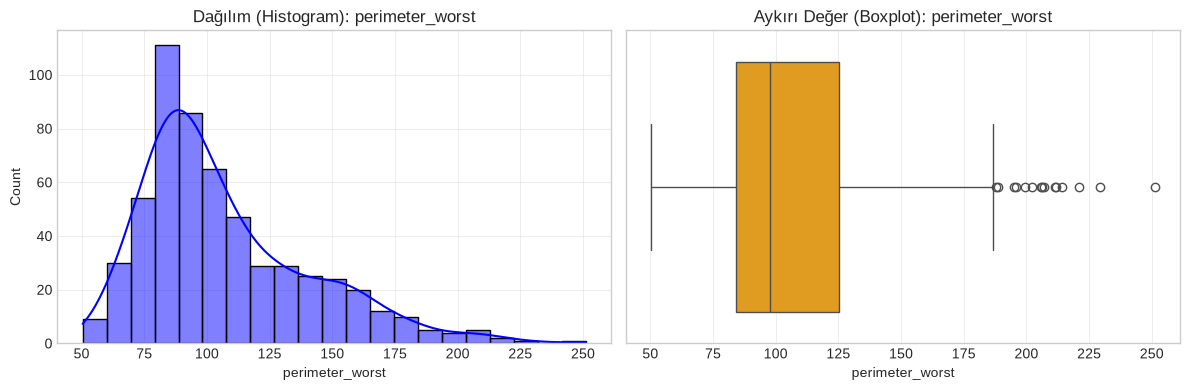

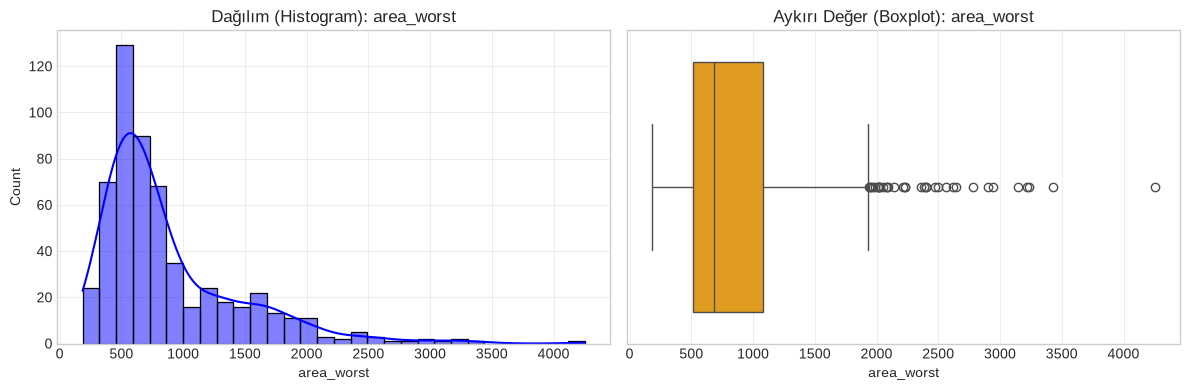

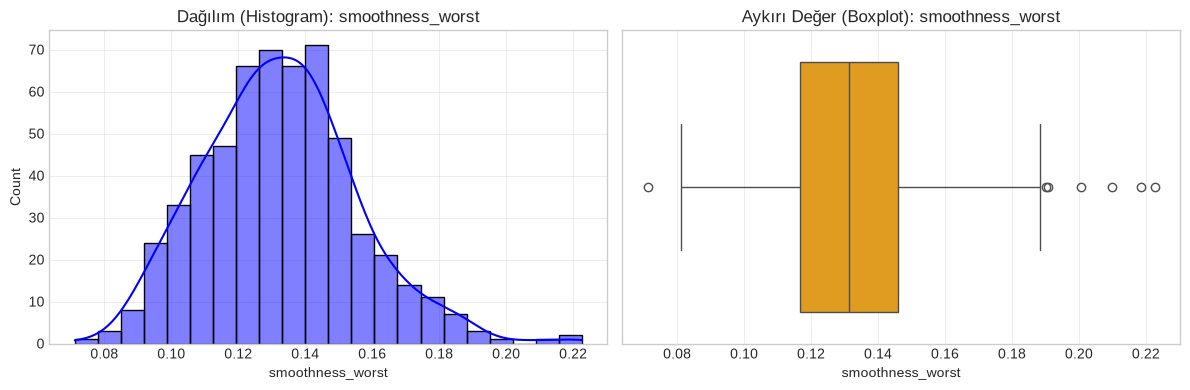

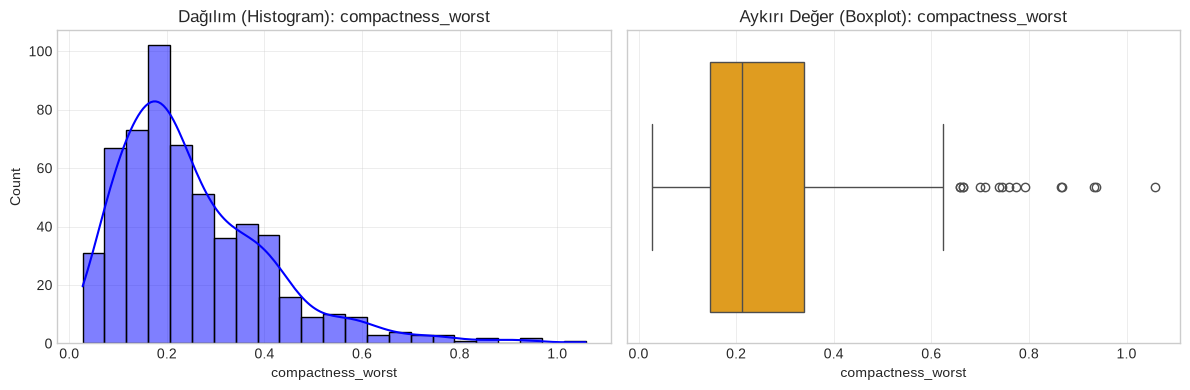

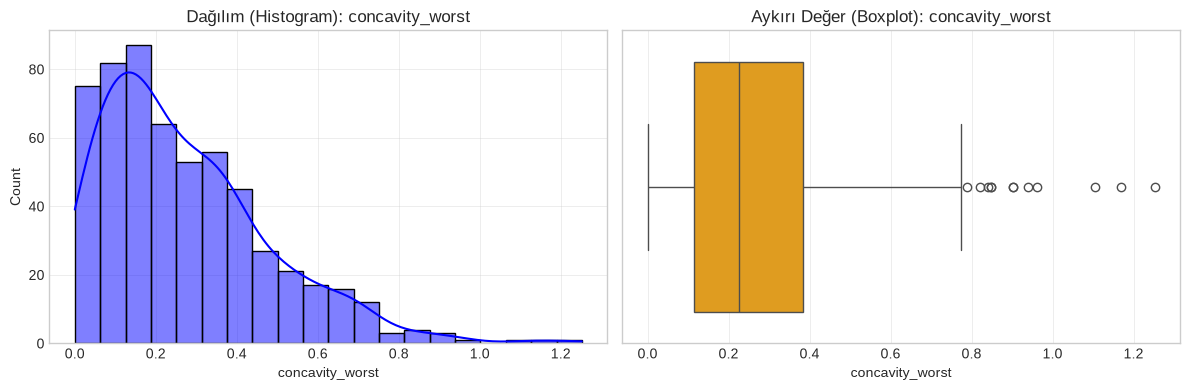

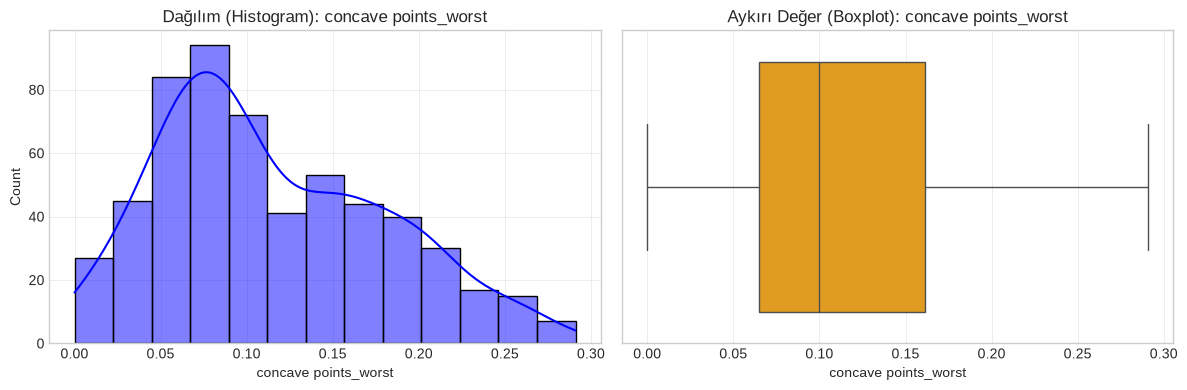

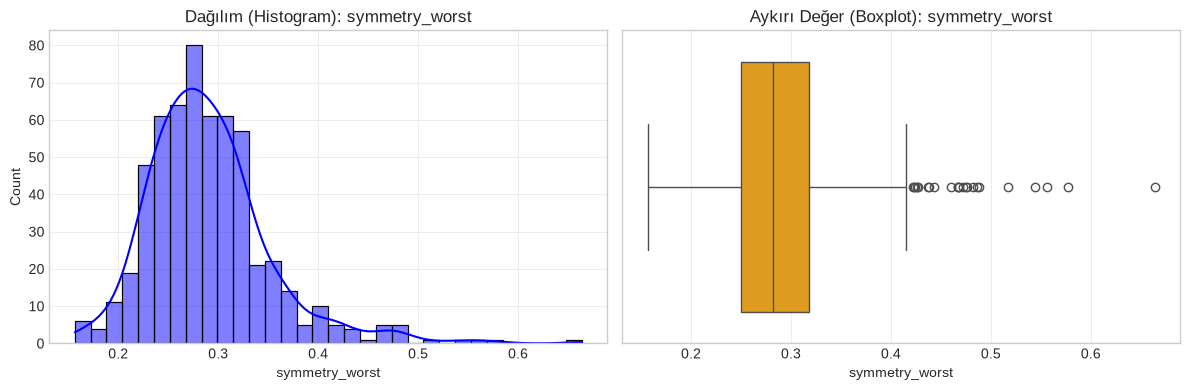

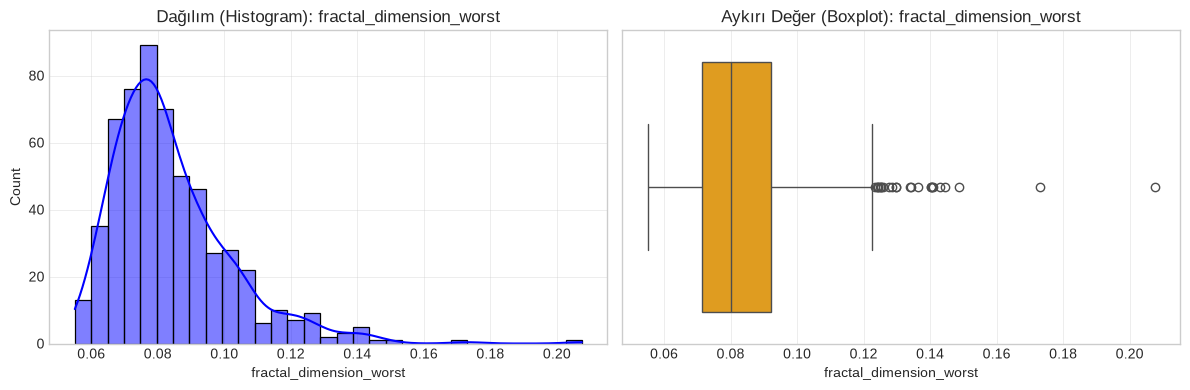

In [4]:
# --- 2. İstatistiksel Dağılım ---
# Tüm veriler sayısal olduğu için hepsini seç
numerical_cols = df.drop(columns=["id","Unnamed: 32"])
plot_statistical_distributions(df, numerical_cols)

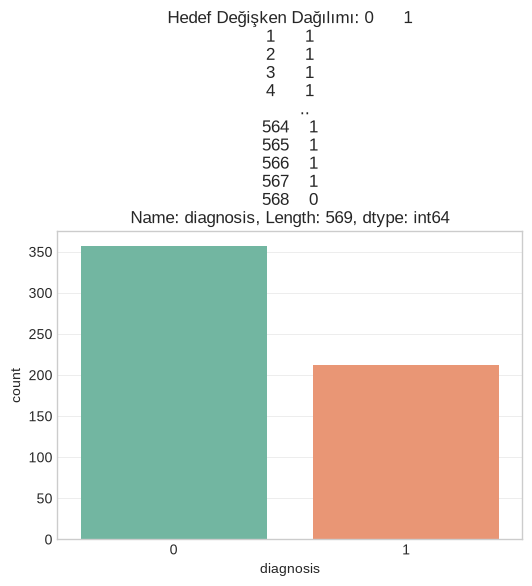

In [5]:
# --- 3. Hedef Değişken (Target) Dağılımı ---
# Hedef sütunu ayarlama
target_column = df["diagnosis"]
plot_target_distribution(df, target_column)

=== Target ile Korelasyon Sıralaması ===
concave points_worst       0.793566
perimeter_worst            0.782914
concave points_mean        0.776614
radius_worst               0.776454
perimeter_mean             0.742636
area_worst                 0.733825
radius_mean                0.730029
area_mean                  0.708984
concavity_mean             0.696360
concavity_worst            0.659610
compactness_mean           0.596534
compactness_worst          0.590998
radius_se                  0.567134
perimeter_se               0.556141
area_se                    0.548236
texture_worst              0.456903
smoothness_worst           0.421465
symmetry_worst             0.416294
texture_mean               0.415185
concave points_se          0.408042
smoothness_mean            0.358560
symmetry_mean              0.330499
fractal_dimension_worst    0.323872
compactness_se             0.292999
concavity_se               0.253730
fractal_dimension_se       0.077972
id                     

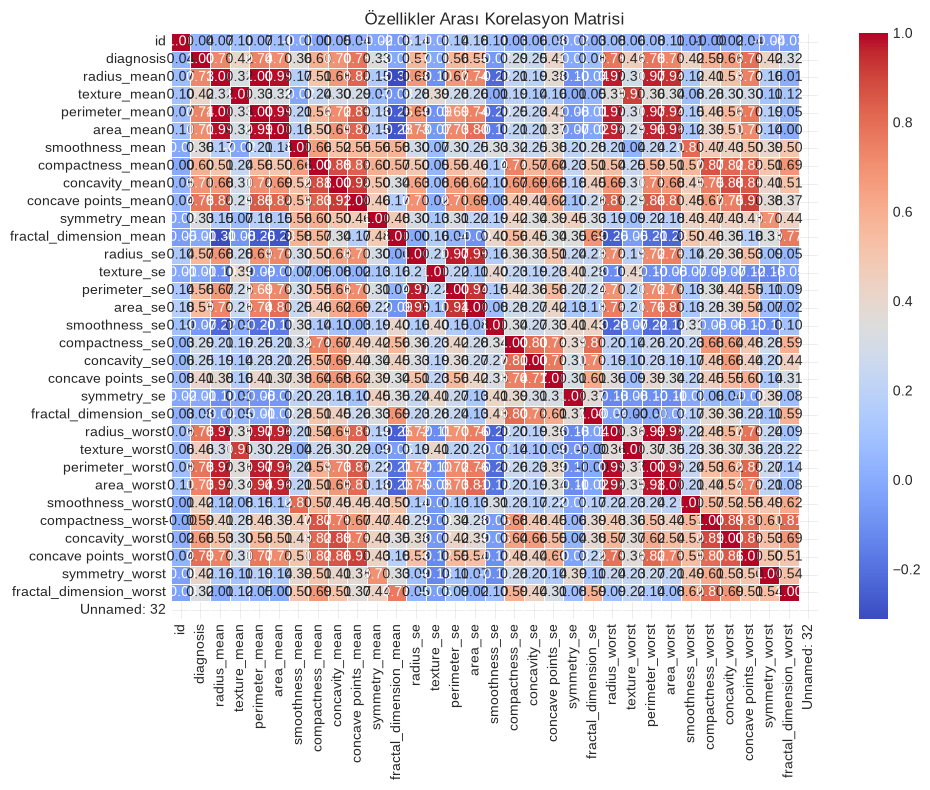

⚠️ Yüksek korelasyonlu (çakışan) özellikler: ['perimeter_mean', 'area_mean', 'concavity_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'compactness_worst', 'concavity_worst', 'concave points_worst']


In [6]:
# --- 4. Coefficient ve Correlation Eğrileri + Target İlişkisi ---
target_corr, to_drop = analyze_feature_correlations(df, target_col="diagnosis")

In [7]:
# --- 5. Verinin Eğitim ve Test Olarak Ayrılması ---
X = df.drop(columns=["diagnosis","id"])
y = df["diagnosis"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"\n5. Veri Bölündü -> Train: {X_train.shape}, Test: {X_test.shape}")


5. Veri Bölündü -> Train: (455, 31), Test: (114, 31)


In [8]:
# --- 6. Outlier Değerleri Belirleme ---
X_train_clipped, X_test_clipped, outlier_summary = apply_iqr_clipping(X_train, X_test, numerical_cols)

=== Aykırı Değer (Outlier) Sayıları ===
🔸 radius_mean: 11 adet aykırı değer bulundu.
🔸 texture_mean: 5 adet aykırı değer bulundu.
🔸 perimeter_mean: 12 adet aykırı değer bulundu.
🔸 area_mean: 20 adet aykırı değer bulundu.
🔸 smoothness_mean: 5 adet aykırı değer bulundu.
🔸 compactness_mean: 14 adet aykırı değer bulundu.
🔸 concavity_mean: 17 adet aykırı değer bulundu.
🔸 concave points_mean: 9 adet aykırı değer bulundu.
🔸 symmetry_mean: 13 adet aykırı değer bulundu.
🔸 fractal_dimension_mean: 12 adet aykırı değer bulundu.
🔸 radius_se: 31 adet aykırı değer bulundu.
🔸 texture_se: 15 adet aykırı değer bulundu.
🔸 perimeter_se: 34 adet aykırı değer bulundu.
🔸 area_se: 53 adet aykırı değer bulundu.
🔸 smoothness_se: 20 adet aykırı değer bulundu.
🔸 compactness_se: 24 adet aykırı değer bulundu.
🔸 concavity_se: 24 adet aykırı değer bulundu.
🔸 concave points_se: 17 adet aykırı değer bulundu.
🔸 symmetry_se: 22 adet aykırı değer bulundu.
🔸 fractal_dimension_se: 23 adet aykırı değer bulundu.
🔸 radius_wors

In [9]:
# --- 7. Correlation Filtresi (Clipping Sonrasında) ---
X_train_corr, X_test_corr = correlation_filter(
    X_train_clipped, X_test_clipped, corr_threshold=0.85
)

9. Korelasyon Filtresi Sonrası Kalan Özellik Sayısı: 17


In [10]:
# --- Sabit (Constant) Sütunları Temizleme ---
constant_cols = [col for col in X_train_corr.columns if X_train_corr[col].nunique() <= 1]

if constant_cols:
    print(f"Sabit sütunlar tespit edildi ve çıkarılıyor: {constant_cols}")
    X_train_corr = X_train_corr.drop(columns=constant_cols)
    X_test_corr = X_test_corr.drop(columns=constant_cols)
else:
    print("Sabit sütun bulunamadı.")

Sabit sütunlar tespit edildi ve çıkarılıyor: ['Unnamed: 32']


In [11]:
# --- 8. Öznitelik Seçimi (Feature Selection) ---
selected_features = select_best_features_anova(X_train_corr,y_train)
X_train_selected = X_train_corr[selected_features]
X_test_selected = X_test_corr[selected_features]

=== En İyi 5 Özellik (ANOVA / SelectKBest) ===
              Feature       Score
0         radius_mean  563.468797
6           radius_se  311.020617
3    compactness_mean  284.825894
10  concave points_se  117.381504
13   smoothness_worst  104.058664


In [12]:
# Hepsini tek bir pakette topla
bundle = {
    "X_train": X_train_selected,
    "X_test": X_test_selected,
    "y_train": y_train,
    "y_test": y_test,
}
# Tek dosyaya kaydet
joblib.dump(bundle, "../backend/models/cancer/cancer_data_bundle.pkl")
print(
    "İşlenmiş cancer veri setleri başarıyla backend/models/cancer/"
    " klasörüne kaydedildi!"
)

İşlenmiş cancer veri setleri başarıyla backend/models/cancer/ klasörüne kaydedildi!
